# RAPID Example
This notebook loads the RAPID AMOC transport record from the CSV in `notebook_examples/` and tests whether its fitted linear trend stands out relative to phase-scrambled surrogate series.

A possible AMOC slowdown under climate change is important but still uncertain. The RAPID record is also strongly persistent from month to month, so a standard trend test is not a good fit. Here we compare the calculated trend against many surrogate series that keep the same overall variability but scramble the timing.


## 1. Imports
Load the RAPID CSV, convert it to an xarray time series, and use the polynomial trend significance tools from the package.

In [24]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from SpectralCorr import phase_scrambled_surrogates, polynomial_coefficient_significance


## 2. Load the RAPID record
The RAPID array provides a monthly AMOC transport estimate. The CSV stores year and month separately, so we convert them to a decimal-year time coordinate before building the xarray `DataArray`.


In [25]:
df = pd.read_csv("./amoc_rapid_RAPID.csv", comment="#")
decimal_time = df["Year"] + (df["Month"] - 1) / 12

rapid = xr.DataArray(
    df["RAPID (Sv)"].to_numpy(),
    dims=["time"],
    coords={"time": decimal_time.to_numpy()},
    name="RAPID_transport",
    attrs={"description": "RAPID transport (Sv)", "units": "Sv"},
)
rapid = rapid - rapid.mean('time')

## 3. Test the linear trend coefficient
For a first-degree polynomial, `degree=1` is the trend term and `degree=0` is the intercept. This cell fits the trend and compares it against surrogate trends.


In [26]:
n_surrogates = 500_000

result = polynomial_coefficient_significance(
    rapid,
    degree=1,
    n_surrogates=n_surrogates,
    detrend=None,
    alternative="less",
    return_distributions=True,
)

trend = result["polynomial_coefficient"].sel(degree=1)
trend_pvalue = result["polynomial_coefficient_pvalue"]

## 4. Plot the significance test
The left panel shows many surrogate time series together with the RAPID record. The right panel shows the surrogate trend distribution and marks the calculated trend.


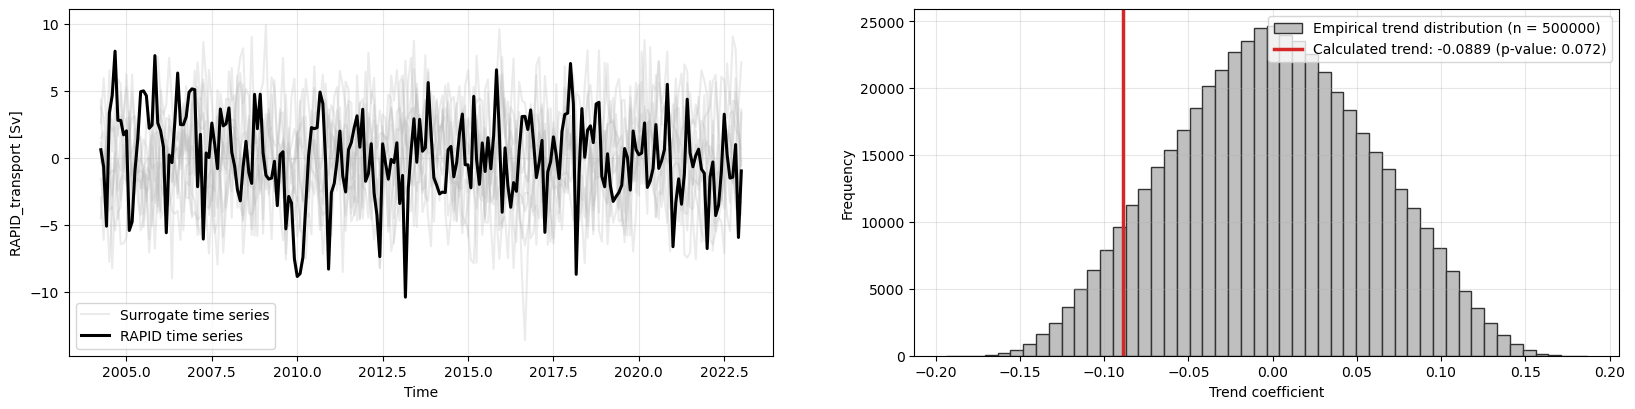

In [27]:
#surrogates for plotting, seperate from the those used for testing
plot_surrogates = phase_scrambled_surrogates(
    rapid,
    detrend=None,
    n_surrogates=10,
)

surrogate_trends = result["polynomial_coefficient_distribution"].sel(degree=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 4.5))

for i in plot_surrogates["surrogate"]:
    label = None
    if i == 0:
        label = "Surrogate time series"
    plot_surrogates.sel(surrogate=i).plot(ax=axes[0], color="0.7", alpha=0.25, label=label)

rapid.plot(ax=axes[0], color="black", linewidth=2.2, label="RAPID time series")
axes[0].set_xlabel("Time")

axes[1].hist(surrogate_trends, bins=50, color="0.75", edgecolor="0.2", label=f"Empirical trend distribution (n = {n_surrogates})")
axes[1].axvline(
    float(trend),
    color="C3",
    linewidth=2.5,
    label=f"Calculated trend: {float(trend):.4f} (p-value: {(trend_pvalue):.3f})",
)
axes[1].set_xlabel("Trend coefficient")
axes[1].set_ylabel("Frequency")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)


## 5. Inspect the result dataset
The result dataset keeps the fitted coefficients, the empirical p value for the tested degree, and the optional surrogate coefficient distribution.


In [28]:
result

<xarray.Dataset> Size: 12MB
Dimensions:                              (degree: 2, bootstrap_iter: 500000)
Coordinates:
  * degree                               (degree) int64 16B 1 0
  * bootstrap_iter                       (bootstrap_iter) int64 4MB 0 ... 499999
Data variables:
    polynomial_coefficient               (degree) float64 16B -0.08891 179.0
    polynomial_coefficient_pvalue        float64 8B 0.07188
    polynomial_coefficient_distribution  (bootstrap_iter, degree) float64 8MB ...
Attributes:
    description:        Polynomial coefficient significance
    degree:             1
    n_samples:          226
    n_surrogates:       500000
    dt:                 0.08333333333325754
    alternative:        less
    surrogate_detrend:  None